In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_dir = "/Users/cul434/Library/CloudStorage/Dropbox/Jellyfish_Data"
datasets = ["Homeostasis_1", "Homeostasis_2", "Regeneration_1", "Regeneration_2"]
n_datasets = len(datasets)

In [3]:
processed_data = {}
for dataset in datasets:
    print(f"Dataset: {dataset}")    
    neurons = pd.read_csv(data_dir + "/" + dataset + "/final_nomouth.csv")
    mouth = pd.read_csv(data_dir + "/" + dataset + "/mouth.csv")
    neurons = neurons.sort_values(["track_id", "t"])
    mouth_x = mouth['x'].values[0]
    mouth_y = mouth['y'].values[0]
    neurons['x_norm'] = neurons.x - mouth_x
    neurons['y_norm'] = neurons.y - mouth_y
    neurons['r'] = np.sqrt(neurons.x_norm**2 + neurons.y_norm**2)
    neurons['theta'] = np.arctan2(neurons.y_norm, neurons.x_norm)
    processed_data[dataset] = neurons

Dataset: Homeostasis_1
Dataset: Homeostasis_2
Dataset: Regeneration_1
Dataset: Regeneration_2


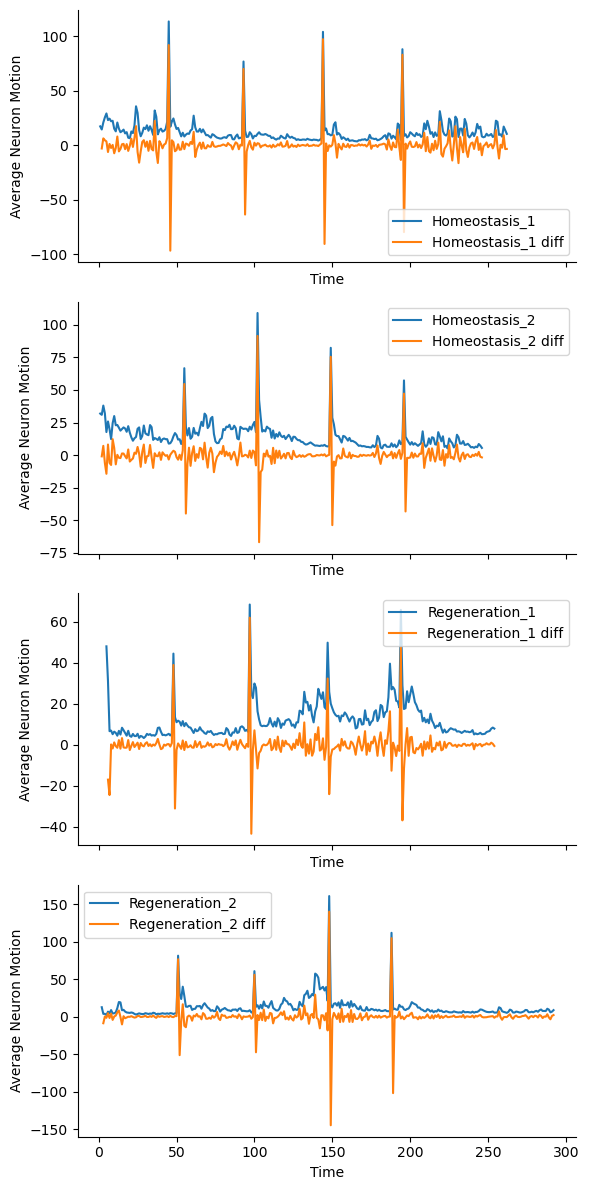

In [4]:
# now, for each dataset, for each timestep, I want to compute how much "total motion" there is, averaged across all neurons. it's ok to do this in x and y coordinites

fig, axs = plt.subplots(n_datasets, 1, figsize=(6, 3*n_datasets), sharex=True)
for dataset in datasets:
    neurons = processed_data[dataset]
    neurons['dx'] = neurons.groupby('track_id')['x_norm'].diff()
    neurons['dy'] = neurons.groupby('track_id')['y_norm'].diff()
    neurons['motion'] = np.sqrt(neurons.dx**2 + neurons.dy**2)
    motion_by_time = neurons.groupby('t')['motion'].mean()
    diff_motion_by_time = motion_by_time.diff()
   # second_diff_motion_by_time = diff_motion_by_time.diff()
    axs[datasets.index(dataset)].plot(motion_by_time.index, motion_by_time.values, label=dataset)
    axs[datasets.index(dataset)].plot(diff_motion_by_time.index, diff_motion_by_time.values, label=dataset + " diff")
   # axs[datasets.index(dataset)].plot(second_diff_motion_by_time.index, second_diff_motion_by_time.values, label=dataset + " second diff")
    axs[datasets.index(dataset)].legend()
    axs[datasets.index(dataset)].set_xlabel("Time")
    axs[datasets.index(dataset)].set_ylabel("Average Neuron Motion")

sns.despine()
plt.tight_layout()
plt.show()


Dataset: Homeostasis_1, Threshold: 20, Jumps: 6
Dataset: Homeostasis_1, Threshold: 30, Jumps: 4
Dataset: Homeostasis_1, Threshold: 40, Jumps: 4
Dataset: Homeostasis_1, Threshold: 50, Jumps: 4
Dataset: Homeostasis_2, Threshold: 20, Jumps: 4
Dataset: Homeostasis_2, Threshold: 30, Jumps: 4
Dataset: Homeostasis_2, Threshold: 40, Jumps: 4
Dataset: Homeostasis_2, Threshold: 50, Jumps: 3
Dataset: Regeneration_1, Threshold: 20, Jumps: 4
Dataset: Regeneration_1, Threshold: 30, Jumps: 4
Dataset: Regeneration_1, Threshold: 40, Jumps: 2
Dataset: Regeneration_1, Threshold: 50, Jumps: 1
Dataset: Regeneration_2, Threshold: 20, Jumps: 5
Dataset: Regeneration_2, Threshold: 30, Jumps: 4
Dataset: Regeneration_2, Threshold: 40, Jumps: 4
Dataset: Regeneration_2, Threshold: 50, Jumps: 4


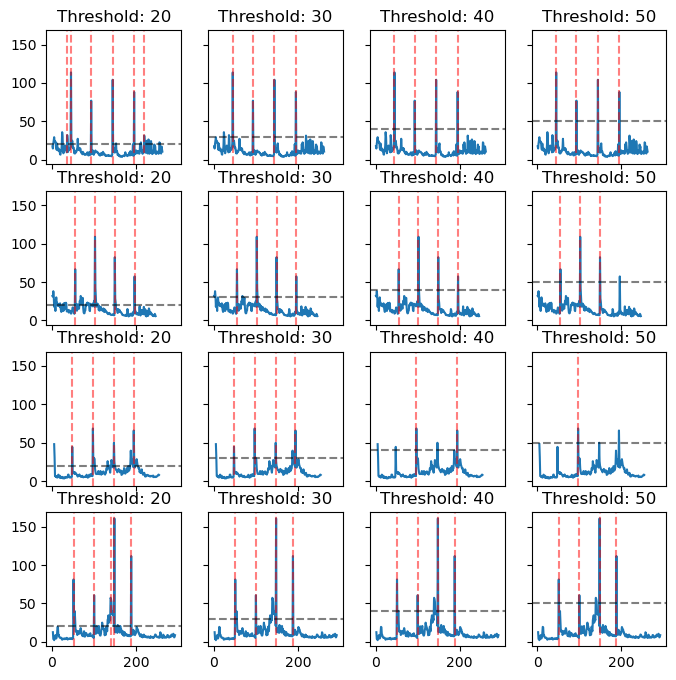

In [5]:
thresholds = [20, 30, 40, 50]
fig, axs = plt.subplots(n_datasets, len(thresholds), figsize=(2*len(thresholds), 2*n_datasets), sharex=True, sharey=True)
for dataset in datasets:
    for threshold in thresholds:
        neurons = processed_data[dataset]
        motion_by_time = neurons.groupby('t')['motion'].mean()
        diff_motion_by_time = motion_by_time.diff()
        jumps = diff_motion_by_time[diff_motion_by_time > threshold]
        ax = axs[datasets.index(dataset), thresholds.index(threshold)]
        ax.plot(motion_by_time.index, motion_by_time.values)
        for t_jump in jumps.index:
            ax.axvline(x=t_jump, color='red', linestyle='--', alpha=0.5)
        ax.axhline(threshold, color='black', linestyle='--', alpha=0.5)
        ax.set_title(f"Threshold: {threshold}")
        print(f"Dataset: {dataset}, Threshold: {threshold}, Jumps: {len(jumps)}")

In [6]:
# based on this analysis, a threshold of 30 works for all datasets. 

# this is still true when including the newest dataset,  Homeostasis_2. (5/28/2026)
# no further proccessing wil be needed 
threshold = 30

for dataset in datasets:
    neurons = processed_data[dataset]
    motion_by_time = neurons.groupby('t')['motion'].mean()
    diff_motion_by_time = motion_by_time.diff()
    jumps = diff_motion_by_time[diff_motion_by_time > threshold]
    jump_times = jumps.index.values

    
    # Now, create a column in the original dataframe that indicates whether a jump event is happening at each time step
    neurons['jump'] = False
    for t in jump_times:
        neurons.loc[neurons['t'] == t, 'jump'] = True
    
    processed_data[dataset] = neurons


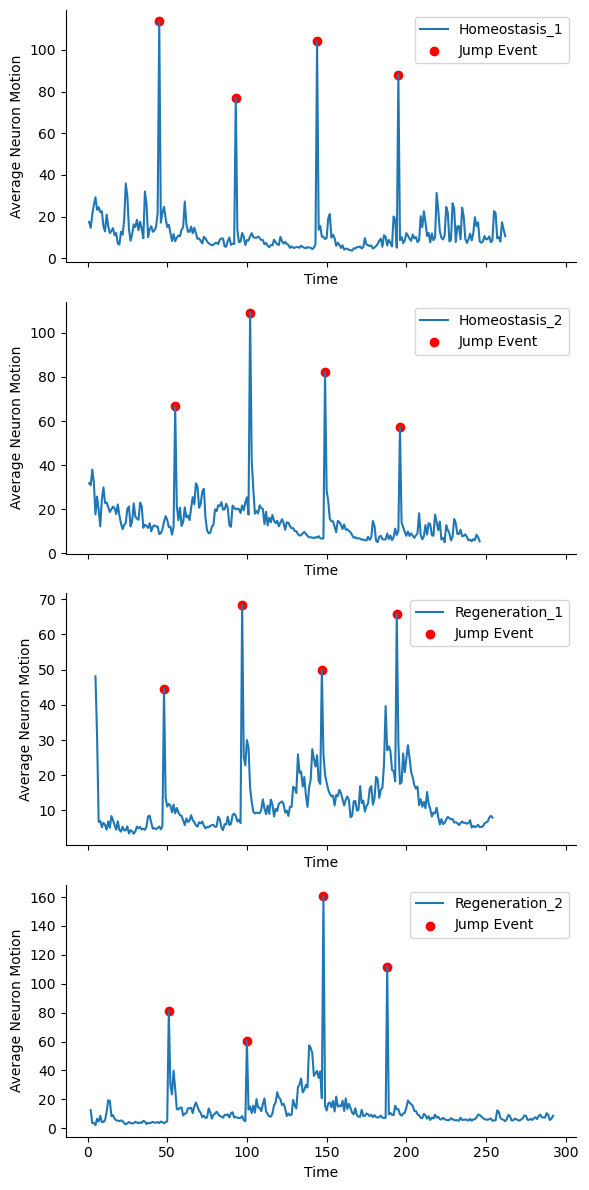

In [7]:
#sanity check: plot the jump events on top of the motion by time plot
fig, axs = plt.subplots(n_datasets, 1, figsize=(6, 3*n_datasets), sharex=True)
for dataset in datasets:
    neurons = processed_data[dataset]
    motion_by_time = neurons.groupby('t')['motion'].mean()
    jump_events = neurons.groupby('t')['jump'].any()
    axs[datasets.index(dataset)].plot(motion_by_time.index, motion_by_time.values, label=dataset)
    axs[datasets.index(dataset)].scatter(jump_events[jump_events].index, motion_by_time[jump_events], color='red', label='Jump Event')
    axs[datasets.index(dataset)].legend()
    axs[datasets.index(dataset)].set_xlabel("Time")
    axs[datasets.index(dataset)].set_ylabel("Average Neuron Motion")

sns.despine()
plt.tight_layout()
plt.show()

In [8]:
# each jump corresponds to a time when the jellyfish is taken off the microscope to recover 
# the jellyfish is off the scope for 8 hours, so timesteps after a jump event are 8 hours after the previous timestep 
# otherwise, successive time frames are separated by 20 minutes
# we use this to add a new column to the dataframe that indicates the "real time" of each time step, which accounts for the jump events.

for dataset in datasets:
    neurons = processed_data[dataset].copy()

    # One jump flag per timestep
    jump_by_t = neurons.groupby('t')['jump'].any().sort_index()
    t_vals = jump_by_t.index.to_numpy()

    # Build real time (minutes) once per timestep
    real_time_by_t = pd.Series(index=t_vals, dtype=float)
    real_time_by_t.iloc[0] = 0.0  # start at 0 minutes

    for k in range(1, len(t_vals)):
        # If this timestep is marked as jump, gap from previous is 8 hours; else 20 min
        delta = 8 if jump_by_t.iloc[k] else (20/60)  # convert 20 min to hours
        real_time_by_t.iloc[k] = real_time_by_t.iloc[k - 1] + delta

    # Assign back to every row with same timestep
    neurons['real_time'] = neurons['t'].map(real_time_by_t).round(2)

    processed_data[dataset] = neurons

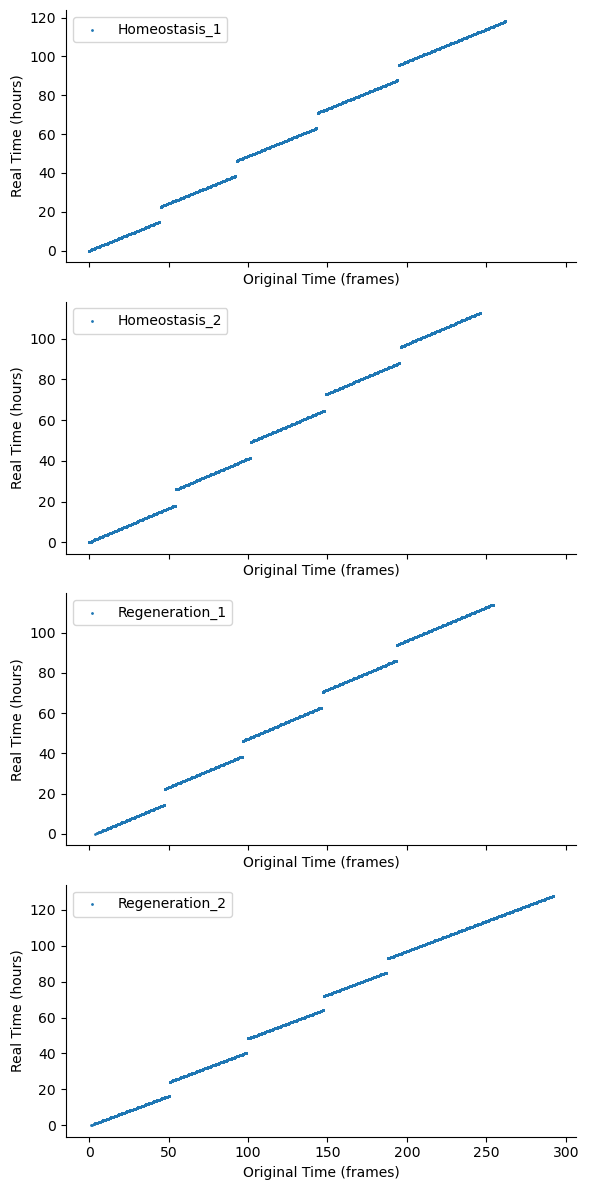

In [9]:
# sanity chec: plot the real time vs the original time to make sure it looks right
fig, axs = plt.subplots(n_datasets, 1, figsize=(6, 3*n_datasets), sharex=True)
for dataset in datasets:
    neurons = processed_data[dataset]
    axs[datasets.index(dataset)].scatter(neurons['t'], neurons['real_time'], label=dataset, s = 1)
    axs[datasets.index(dataset)].legend()
    axs[datasets.index(dataset)].set_xlabel("Original Time (frames)")
    axs[datasets.index(dataset)].set_ylabel("Real Time (hours)")

sns.despine()
plt.tight_layout()
plt.show()

In [10]:
print(f"120 hours is {120/24} days")

120 hours is 5.0 days


In [11]:
# everything checks out. We now want to save the processed dataframes with the new "real_time" column for use in future analyses.
for dataset in datasets:
    neurons = processed_data[dataset]
    neurons.to_csv(data_dir + "/" + dataset + "/final_nomouth_processed.csv", index=False)